In [3]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

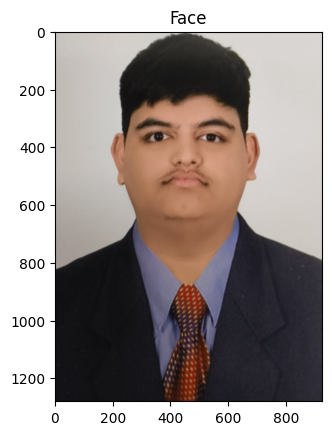

In [4]:
# Load the Face Image
faceImage = cv2.imread('mypic..jpg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [5]:
faceImage.shape

(1280, 926, 3)

In [6]:
#resized_faceImage.shape
faceImage.shape

(1280, 926, 3)

Text(0.5, 1.0, 'glassPNG')

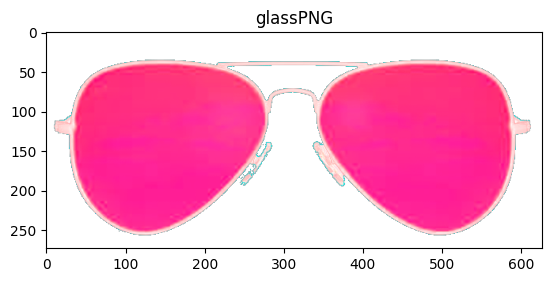

In [7]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('sunglass.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [8]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(350,80))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(80, 350, 4)


In [9]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

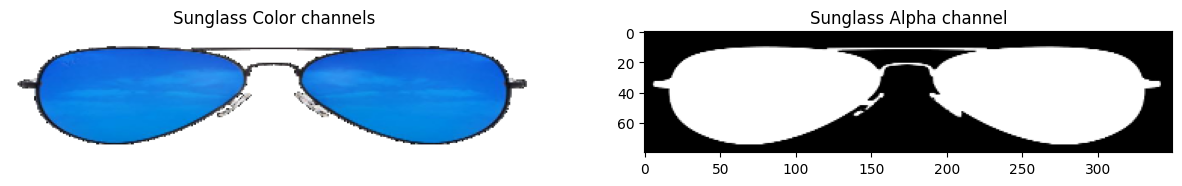

In [15]:
# Copy the image
result = glassBGR.copy()

# Replace background (where mask == 0) with white
result[glassMask1 == 0] = [255, 255, 255]

# Show result
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(result[:, :, ::-1])
plt.title("Sunglass Color channels")
plt.axis('off')
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

(np.float64(-0.5), np.float64(925.5), np.float64(1279.5), np.float64(-0.5))

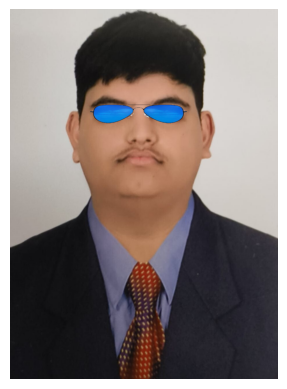

In [17]:
# Make a copy
faceWithGlassesNaive = faceImage.copy()

# Region where glasses go
y1, y2 = 320, 400
x1, x2 = 270, 620

# Resize glasses + mask to match that region
glass_resized = cv2.resize(glassBGR, (x2 - x1, y2 - y1))
mask_resized = cv2.resize(glassMask1, (x2 - x1, y2 - y1))

# Clean mask (removes gray edges)
_, mask_resized = cv2.threshold(mask_resized, 240, 255, cv2.THRESH_BINARY)

# Get ROI from face
roi = faceWithGlassesNaive[y1:y2, x1:x2]

# Apply mask directly (this is the key fix)
roi[mask_resized == 255] = glass_resized[mask_resized == 255]

# Put ROI back
faceWithGlassesNaive[y1:y2, x1:x2] = roi

# Show
plt.imshow(faceWithGlassesNaive[..., ::-1])
plt.axis('off')

Text(0.5, 1.0, 'Augmented Eye and Sunglass')

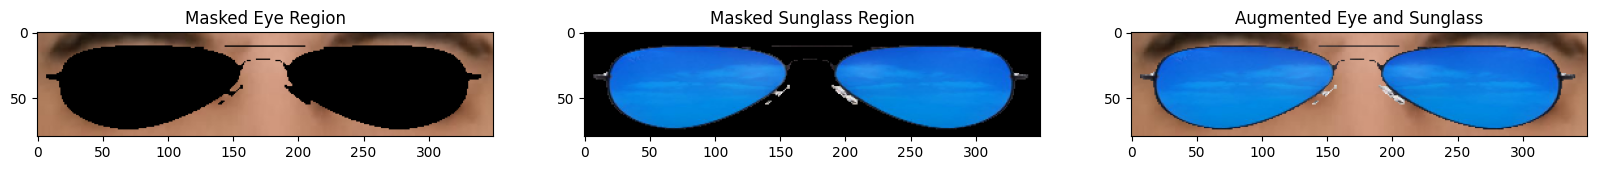

In [19]:
# Make the dimensions of the mask same as the input image.
# Since Face Image is a 3-channel image, we create a 3 channel image for the mask
glassMask = cv2.merge((glassMask1,glassMask1,glassMask1))

# Make the values [0,1] since we are using arithmetic operations
glassMask = np.uint8(glassMask/255)

# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Get the eye region from the face image
eyeROI= faceWithGlassesArithmetic[320:400, 270:620]

# Use the mask to create the masked eye region
maskedEye = cv2.multiply(eyeROI,(1-  glassMask ))

# Use the mask to create the masked sunglass region
maskedGlass = cv2.multiply(glassBGR,glassMask)

# Combine the Sunglass in the Eye Region to get the augmented image
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Display the intermediate results
plt.figure(figsize=[20,20])
plt.subplot(131);plt.imshow(maskedEye[...,::-1]);plt.title("Masked Eye Region")
plt.subplot(132);plt.imshow(maskedGlass[...,::-1]);plt.title("Masked Sunglass Region")
plt.subplot(133);plt.imshow(eyeRoiFinal[...,::-1]);plt.title("Augmented Eye and Sunglass")

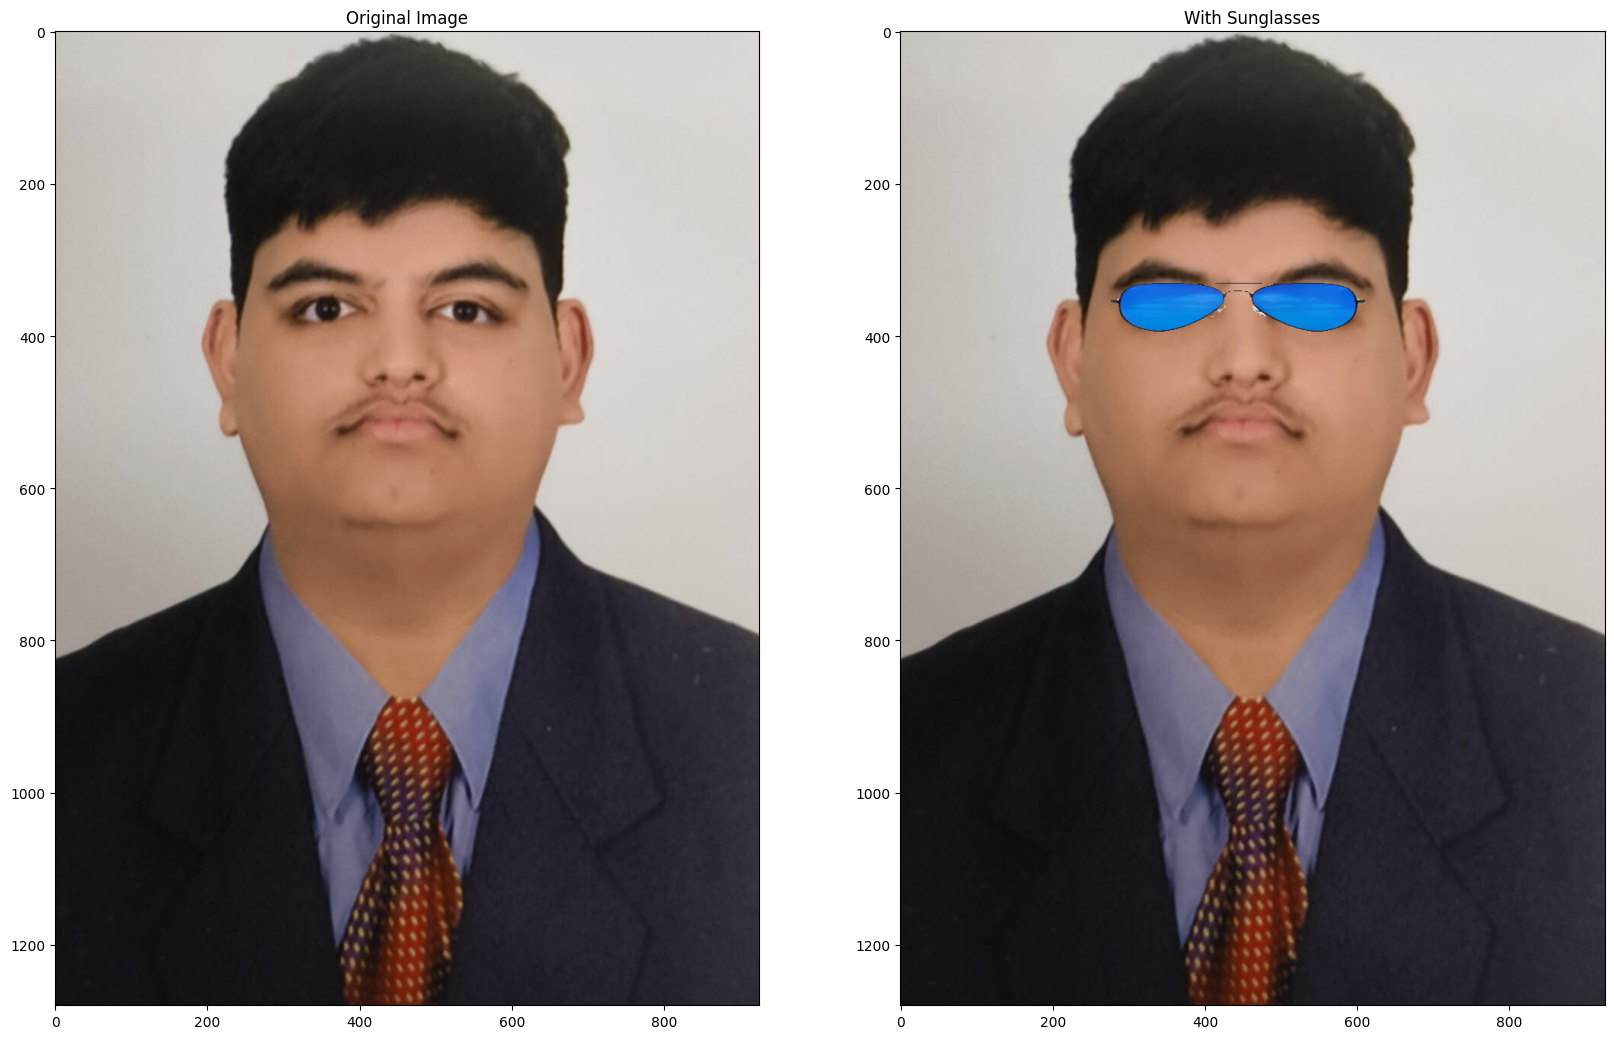

In [20]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[320:400, 270:620]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");